# **9주차 과제**


- Colab 환경에서는 마크다운 셀의 보이지 않을 수 있으니, VS Code 등의 로컬환경을 사용하시거나 참고이미지 폴더의 파일들을을 참고하시길 바랍니다.

- 해당 과제는 VS Code, MySQL Workbench 환경에서 제작되었습니다.

- 출력 형태를 보며 display를 활용한 출력, print를 활용한 출력을 적절하게 사용해주시길 바랍니다.  
※ 이를 준수하지 않을 시에 오답의 요소가 될 수 있습니다.

---
## **Q1. Selenium을 실행하여 티스토리 메인 홈페이지로 이동**

<img src="./9th_Weeks_images/Q1_Image_1.png" alt="1" style="width:60%; height:auto;">

- 상단에 첨부된 이미지 화면은 크롤링을 수행하는 시점마다 다르게 표현됩니다.

- 주소는 tstory url : https://www.tistory.com 을 사용해주세요

In [3]:
# 코드 작성

''' 정답 코드를 작성해주세요 '''

from selenium import webdriver
from selenium.webdriver.common.by import By
import time
from bs4 import BeautifulSoup
import pandas as pd

# Selenium으로 웹 드라이버를 실행을 실행합니다.
driver = webdriver.Chrome()

# url 전달을 전달합니다.
url = 'https://www.tistory.com'
driver.get(url)
time.sleep(5)

---
## Q2. BeautifulSoup을 통해 html 정보 가져오고, 인기글 제목 출력
- 아래는 예시 이미지이며, 크롤링 수행시간마다 다르게 표현될 수 있습니다.
- 예시 이미지 기준으로 1, 2, 3, 4, 5 우측에 있는 글 제목을 출력하면 됩니다.
- 크롤링은 실시간으로 변하는 데이터이므로, 채점 시에 직접 실행해보고 결과 데이터를 확인하겠습니다.

<img src="./9th_Weeks_images/Q1_Image_1.png" alt="1" style="width:60%; height:auto;">

In [4]:
''' 정답 코드를 작성해주세요 '''

# 수행방법입니다.
# tag와 class 정보 확인해주세요
# find_all을 통해 정보 가져옵니다.

html_doc = driver.page_source
soup = BeautifulSoup(html_doc, 'html.parser')

# soup
# 상위 5개 데이터를 출력해주세요
for content in soup.find_all('div', class_='cont_g'): # 반복문 구성
    print(content.find_all('strong', class_='tit_g')[0].text)

한입 가득 달콤함 풍미 폭발~ 허니버터고구마 레시피
전주식 백반 정식의 품격! 갈치구이와 조림을 주문했더니 한정식급 상차림이 뙇! 갓 지은 압력밥솥은 덤~ 전주전통비빔밥~!
파김치 맛있게 담그는법 입에 착 감기는 파김치 양념 만드는법
외국인들이 일본을 찾는 공통된 이유
감자송편과 국화향 사이로 흐르는 따뜻한 하루


---
## Q3. 메타코드 정보 검색, 데이터프레임으로 정보 저장

<img src="./9th_Weeks_images/Q3_Image_1.png" alt="1">

- 상단 이미지는 검색 시에 나타나는 화면의 일부입니다.  

- 1 드라이버에서 메타코드를 검색창에 입력합니다.  

- 2 검색 버튼을 클릭하세요.
    - 클릭 기능 사용 방법 추가로 첨부드립니다  
    : driver.find_element(By.CSS_SELECTOR, '요소 정보').click()

※ 모든 동작은 크롤링을 통해 수행되어야 합니다.

In [ ]:
driver.find_element(By.CSS_SELECTOR , '#kakaoHead > div > div.group_head > div.search_group > div.search_tistory.write_on > form > fieldset > div > div > input[type=text]').send_keys('메타코드')
time.sleep(2)
click_button = driver.find_element(By.CSS_SELECTOR, '#kakaoHead > div > div.group_head > div.search_group > div.search_tistory.search_on > form > fieldset > div > button.btn_search > span.img_common_tistory_v1.ico_search_black')
click_button.click()
time.sleep(4)

In [5]:
''' 정보 수집 및 상위 10개 데이터 출력 코드를 작성해주세요 '''

# 정보 수집하고 상위 10개 데이터 출력합니다.,
soup = BeautifulSoup(driver.page_source, 'html.parser')
dict_info = {'제목' : [], '작성자' : [], 0:[], 1:[], 2:[]}

for i in soup.find_all('div', class_ = 'item_group'):
    dict_info['작성자'].append(i.find('span', class_ = 'txt_g').text)
    dict_info['제목'].append(i.find('strong', class_='tit_cont').text)
    wrap_info = i.find('div', class_ = 'wrap_info')
    for idx, i in enumerate(wrap_info.find_all('span', class_='txt_g')):
        dict_info[idx].append(i.text)

meta_info = pd.DataFrame(dict_info)
meta_info.rename({0:'좋아요', 1:'댓글수', 2:'작성일'}, axis=1, inplace=True)
meta_info.head(10)

,제목,작성자,좋아요,댓글수,작성일
0,청와대는 못가봤어도 여기는 가봤다_ 순대국 찐맛!,맛의 마술사 하이디의 뚝딱스토리,23,14,5일 전
1,"수원 갈비 맛집 - 수원 3대 갈비 中 한곳 <신라갈비> 가격과 메뉴, tv 방영 맛집",보득's 세상을 다가져~!,9,4,4일 전
2,펄펄끓는이맛을 누가이길쏘냐 감칠맛나는 김치찌게불맛나는고등어구이(신논현역맛집부뚜막한식집,LIFE is 즐먹마놀,35,46,6일 전
3,“이 한입 때문에 속초 가는 이유가 생겼다!”,맛있는게 좋아♡,8,10,1일 전
4,"가을, 참 이쁘다-담양 창평슬로시티 삼지내마을",tour of wind,119,69,1일 전
5,"호주 6회 종합 챔피언 Lazzio 라찌오 디카페인 커피, 고급 원두지만 저렴한 커...",룰루제이 호주 라이프,111,90,1일 전
6,아차산 맛집 하산하고 오다가 들리기 좋은 명가순대국,예자매아빠의 미식여행,3,2,1일 전
7,보라빛으로 피어나는 가을-담양 대나무박물관 쑥부쟁이,tour of wind,104,46,2일 전
8,"경남 진주시 본성동 ""진주성 촉석루""",이종하의 세상사는 이야기,72,56,4일 전
9,"조선의 여인천하 태릉(泰陵)과 강릉(康陵), 나무숲길 산책",Photo & Movie 행복나눔터,48,44,1일 전


---
## Q4. 자료형 변경 및 시각화를 수행해주세요

**출력 1과 출력 2**의 경우 크롤링 시행 시점에 따라,  
자료형 변경이 필요한 경우가 생길 수도 있고, 생기지 않을 수도 있습니다.  
자료형 변경이 필요하지 않은 경우에는, 진행하지 않으셔도 무관합니다.

**데이터 정보 확인 및 전처리를 수행해주세요**
- 현재 데이터프레임 자료형 확인해주세요
- 출력 결과와 동일하게 자료형 변형해주세요

**출력 1 : 자료형 변경 이전의 출력 결과를 출력해주세요**

In [13]:
# 정답코드를 작성해주세요
print('출력 1 : 자료형 변경 이전의 출력 결과를 출력해주세요')
display(meta_info.info())
meta_info['좋아요'] = meta_info['좋아요'].astype('int')

출력 1 : 자료형 변경 이전의 출력 결과를 출력해주세요
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 5 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   제목      150 non-null    object
 1   작성자     150 non-null    object
 2   좋아요     150 non-null    object
 3   댓글수     150 non-null    object
 4   작성일     150 non-null    object
dtypes: object(5)
memory usage: 6.0+ KB


None

**출력 2 : 자료형 변경 이후의 출력 결과를 출력해주세요**

In [14]:
print('출력 2 : 자료형 변경 이후의 출력 결과를 출력해주세요')
meta_info['댓글수'] = meta_info['댓글수'].astype('int')
display(meta_info.info())

출력 2 : 자료형 변경 이후의 출력 결과를 출력해주세요
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 5 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   제목      150 non-null    object
 1   작성자     150 non-null    object
 2   좋아요     150 non-null    int64 
 3   댓글수     150 non-null    int64 
 4   작성일     150 non-null    object
dtypes: int64(2), object(3)
memory usage: 6.0+ KB


None

**출력 3 : 좋아요 상위 5개 글의 작성자, 글의 좋아요, 댓글수 확인를 확인해주세요**

In [15]:
print('출력 3 : 좋아요 상위 5개 글의 작성자, 글의 좋아요, 댓글수 확인를 확인해주세요')
meta_graph = meta_info.sort_values(by='좋아요', ascending=False).head()
meta_graph = meta_graph[['작성자','좋아요','댓글수']]
display(meta_graph)

출력 3 : 좋아요 상위 5개 글의 작성자, 글의 좋아요, 댓글수 확인를 확인해주세요


,작성자,좋아요,댓글수
115,모연 뉴스,9,15
85,모연 뉴스,9,15
145,모연 뉴스,9,15
41,남박사님의 코딩 이야기|청주코딩학원,8,0
11,남박사님의 코딩 이야기|청주코딩학원,8,0


**출력 4: 출력 화면과 동일한 시각화 진행를 진행해주세요**
- 폰트 종류, 색상을 제외한 요소들은 시각화 결과에서 통일해주세요

출력 4: 출력 화면과 동일한 시각화 진행를 진행해주세요


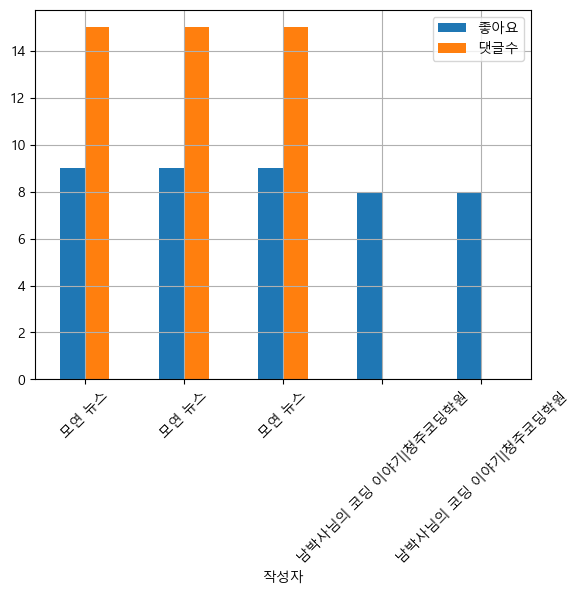

In [16]:
print('출력 4: 출력 화면과 동일한 시각화 진행를 진행해주세요')
import matplotlib.pyplot as plt
plt.rc('font', family='Malgun Gothic')

meta_graph.plot(kind='bar', x='작성자')
plt.xticks(rotation=45)
plt.grid()
plt.show()

---
## Q5 티스토리 자동 페이지 넘기기 기능을 수행하세요

url 주소  

https://www.tistory.com/

1) 웹 드라이버를 실행하고, 티스토리에 접속하세요
2) 검색창에 Python을 입력하세요
3) 검색 버튼 클릭하세요
4) 반복문을 활용하여 5 페이지까지 자동으로 페이지 넘기기를 수행해주세요.

In [8]:
# Selenium으로 웹 드라이버를 실행합니다.
driver = webdriver.Chrome()
url_meta = 'https://www.tistory.com/'

driver.get(url_meta)
driver.find_element(By.CSS_SELECTOR, '#kakaoHead > div > div.group_head > div.search_group > div.search_tistory.write_on > form > fieldset > div > div > input[type=text]').send_keys('Python')
time.sleep(2)
driver.find_element(By.CSS_SELECTOR, '#kakaoHead > div > div.group_head > div.search_group > div.search_tistory.search_on > form > fieldset > div > button.btn_search').click()
time.sleep(2)

for i in range(3, 7):
    print(f'{i-1} 페이지로 이동')
    driver.find_element(By.CSS_SELECTOR, f'#mArticle > div > div.cont_result > div.wrap_paging_tistory > div > a:nth-child({(i)})').click()


2 페이지로 이동
3 페이지로 이동
4 페이지로 이동
5 페이지로 이동


---
## Q5 페이지 자동 이동 및 글 정보 수집 기능

**url 주소 : 'https://www.tistory.com/'**

1) 웹 드라이버를 실행하고, 티스토리에 접속하세요
2) Python이 검색창에 입력되도록 코드를 작성해주세요
3) 검색 버튼이 클릭되도록 코드를 작성해주세요.
4) 반복문을 활용하여 5 페이지까지 자동으로 페이지 넘기는 코드를 작성해주세요
5) 자동 페이지 넘기기가 이루어지는 동안 게시글 정보를 수집하는 코드를 작성해주세요.
   - 수집정보 : 제목, 작성자, 좋아요, 댓글수, 작성일

- 위 과정은 모두 코드를 통해 자동으로 이루어져야 합니다.  

- url 주소 목록들을 활용하여 페이지 이동을 수행할 경우, 정답으로 인정되지 않습니다.

In [10]:
''' 페이지 자동 넘기기 기능과 정보 수집 기능을 합친 코드를 작성해주세요 '''

''' 정답 코드를 작성해주세요 '''

from selenium import webdriver
from selenium.webdriver.common.by import By
import time
from bs4 import BeautifulSoup

# 5페이지까지 자동으로 페이지를 이동합니다.
# 페이지가 넘어갈 때, 글 정보도 함께 수집합니다.
# 제목, 작성자, 좋아요, 댓글수 작성일 정보를 수집해주세요
# 모든 페이지 글 정보를 하나의 데이터프레임에 저장하세요

# Selenium으로 웹 드라이버를 실행하세요
driver = webdriver.Chrome()
url_meta = 'https://www.tistory.com/'
driver.get(url_meta)

# Python을 검색창에 입력하세요
driver.find_element(By.CSS_SELECTOR, '#kakaoHead > div > div.group_head > div.search_group > div.search_tistory.write_on > form > fieldset > div > div > input[type=text]').send_keys('Python')
time.sleep(2)

# 검색 버튼을 클릭하세요
driver.find_element(By.CSS_SELECTOR, '#kakaoHead > div > div.group_head > div.search_group > div.search_tistory.search_on > form > fieldset > div > button.btn_search').click()
time.sleep(2)

soup = BeautifulSoup(driver.page_source, 'html.parser')
dict_info = {'제목' : [], '작성자' : [], 0:[], 1:[], 2:[]}

for i in soup.find_all('div', class_ = 'item_group'):
    dict_info['작성자'].append(i.find('span', class_ = 'txt_g').text)
    dict_info['제목'].append(i.find('strong', class_='tit_cont').text)
    wrap_info = i.find('div', class_ = 'wrap_info')
    for idx, i in enumerate(wrap_info.find_all('span', class_='txt_g')):
        dict_info[idx].append(i.text)

for i in range(3, 7):
    print(f'{i-1} 페이지로 이동')
    driver.find_element(By.CSS_SELECTOR, f'#mArticle > div > div.cont_result > div.wrap_paging_tistory > div > a:nth-child({(i)})').click()
    time.sleep(2)
    soup = BeautifulSoup(driver.page_source, 'html.parser')
    for i in soup.find_all('div', class_ = 'item_group'):
        dict_info['작성자'].append(i.find('span', class_ = 'txt_g').text)
        dict_info['제목'].append(i.find('strong', class_='tit_cont').text)
        wrap_info = i.find('div', class_ = 'wrap_info')
        for idx, i in enumerate(wrap_info.find_all('span', class_='txt_g')):
            dict_info[idx].append(i.text)

    meta_info = pd.DataFrame(dict_info)
    meta_info.rename({0:'좋아요', 1:'댓글수', 2:'작성일'}, axis=1, inplace=True)

2 페이지로 이동
3 페이지로 이동
4 페이지로 이동
5 페이지로 이동


In [11]:
''' 전체 수집된 데이터 중에서 상위 데이터를 출력해주세요 '''

''' 아래 첨부된 이미지는 하위 데이터의 예시 이미지입니다.'''

meta_info.head(5)

,제목,작성자,좋아요,댓글수,작성일
0,[Python] 데이터 시각화,091,0,0,2025.10.14
1,1027 - Python,AI융합 자바풀스택,0,0,2025.10.27
2,[Python] Anaconda 설치 & 가상 환경 구축,domsam - IT 기술 블로그,0,0,2025.10.28
3,Python으로 간단한 업무 자동화 봇 만들기,테크 마일스톤 (Tech Milestone),0,0,2025.10.28
4,"Python(2) | 변수, 문자열 다루기",곤이의 블로그,0,0,2025.10.21


<img src="./9th_Weeks_images/Q6_Image_1.png">

In [12]:
''' 전체 수집된 데이터 중에서 하위 데이터를 출력해주세요 '''

''' 아래 첨부된 이미지는 하위 데이터의 예시 이미지입니다.'''

meta_info.tail(5)

,제목,작성자,좋아요,댓글수,작성일
145,"파이썬 자격증, 취업과 커리어에 얼마나 도움이 될까? Python",모연 뉴스,9,15,2025.08.29
146,[파이썬 정복하기] 점프 투 파이썬 1장 – 파이썬(Python)이란 무엇인가? (...,이 지옥에서 탈출한다,1,1,2025.10.17
147,[파맛] - Python 변수 & 자료형,Noah.log(),1,0,2025.10.17
148,[IOS App] Learn Python Coding: Python X 무료,크라이군 스토리~!,2,10,2025.10.08
149,"데이터 분석 도구 비교 – Python, R, Tableau, Power BI 가이드",호이로그,0,0,2025.10.16


<img src="./9th_Weeks_images/Q6_Image_2.png" alt="1;">

## Q6. 데이터베이스 & 테이블 생성, 데이터 삽입  

※ 지시된 작업을 모두 수행하셔야 하며, 부분 점수는 없습니다.

In [ ]:
''' 데이터 확인용 코드 셀입니다. 참고용으로 확인해주세요 '''

tmp_df = pd.read_csv('./data_sql/Mall_Customers.csv')
display(tmp_df)

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40
...,...,...,...,...,...
195,196,Female,35,120,79
196,197,Female,45,126,28
197,198,Male,32,126,74
198,199,Male,32,137,18


Mall_Customers 데이터 파일을 database에 넣은 뒤에 작업을 진행해주세요  

데이터베이스에 삽입할 데이터는 data_sql 폴더에 있습니다.  

csv와 sql 파일 형식을 모두 제공해드렸으니, 선호하시는 방법으로 database에 데이터를 넣으시면 됩니다.  

데이터베이스와 테이블의 구성 및 생성은 Python이 아닌 MySQL Workbench 환경에서 진행하셔도 됩니다.  
※ 정확하게 데이터베이스의 테이블을 구성하고 생성하는 것 또한 채점에 포함되는 요소입니다.  

문제를 통해 평가하고자 하는 내용은 아래와 같습니다.  

**[수행 작업]**

**<작업 1> 테이블의 모든 데이터 추출**

In [ ]:
'''
정답 쿼리를 작성해주세요

[수행 작업]
<작업 1> 테이블의 모든 데이터 추출
'''

query_all_data = """
SELECT *
FROM mall_customers
"""

import mysql.connector
from mysql.connector import Error
from config import db_config
import pandas as pd

def create_connection():
    try:
        connection = mysql.connector.connect(**db_config.DATABASE_CONFIG)
        if connection.is_connected():
            print('연결 성공')
            return connection
    except Error as e:
        print(f"에러 발생 : {e}")
        return None

connection = create_connection()
cursor = connection.cursor()

''' 해당 코드를 통해 쿼리문의 실행 결과를 출력해주세요'''
''' 데이터 추출, 전처리 등의 작업은 반드시 상단의 SQL 쿼리 작성 셀에서만 진행되어야 합니다.'''
cursor.execute(query_all_data)
result = cursor.fetchall()
columns = [desc[0] for desc in cursor.description]
query_df = pd.DataFrame(result, columns=columns)
query_df

연결 성공


,CustomerID,GENDER,AGE,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15.0,39
1,10,Female,30,19.0,72
2,100,Male,20,61.0,49
3,101,Female,23,62.0,41
4,102,Female,49,62.0,48
...,...,...,...,...,...
195,95,Female,32,60.0,42
196,96,Male,24,60.0,52
197,97,Female,47,60.0,47
198,98,Female,27,60.0,50


**<작업 2> 조건에 맞게 데이터 가공 및 추출**
- 동작 1 : 10세 이상 60대 미만 조건 고객만 선택합니다. 컬럼은 Age 컬럼을 활용합니다.
- 동작 2 : 해당 데이터에서 연령대별로 몇 명의 사람이 있는지 count를 수행합니다.  
※ 데이터에서 새로운 열을 생성하여 작업이 필요한지는 스스로 판단하시면 됩니다.  
※ 최종 결과물에서 집계 결과와 컬럼명이 동일하면 정답으로 인정됩니다.

In [ ]:
query_agg = """
SELECT sub.`Age_Group`, count(sub.CustomerID) as `Count_Result`
from (
	SELECT  mc.CustomerID, mc.GENDER,
			mc.AGE,
	CASE
		   WHEN mc.AGE < 20 THEN '10대'
           WHEN mc.AGE < 30 THEN '20대'
           WHEN mc.AGE < 40 THEN '30대'
           WHEN mc.AGE < 50 THEN '40대'
           WHEN mc.AGE < 60 THEN '50대'
       END AS `Age_Group`,
       mc.`Annual Income (k$)`, mc.`Spending Score (1-100)`
FROM mall_customers mc
WHERE mc.AGE < 60 AND mc.AGE >= 10) sub
GROUP BY sub.`Age_Group`;
"""

''' 해당 코드를 통해 쿼리문의 실행 결과를 출력해주세요'''
''' 데이터 추출, 전처리 등의 작업은 반드시 상단의 SQL 쿼리 작성 셀에서만 진행되어야 합니다.'''

cursor.execute(query_agg)
result = cursor.fetchall()
columns = [desc[0] for desc in cursor.description]
query_df = pd.DataFrame(result, columns=columns)
query_df

,Age_Group,Count_Result
0,10대,12
1,30대,61
2,20대,43
3,40대,39
4,50대,25


## Q7. Python_클래스를 작성해주세요

In [ ]:
''' 데이터 확인용 코드 셀입니다. 참고용으로 확인해주세요 '''
import pandas as pd
tmp_df = pd.read_csv('./data_sql/Mall_Customers.csv')
display(tmp_df)

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40
...,...,...,...,...,...
195,196,Female,35,120,79
196,197,Female,45,126,28
197,198,Male,32,126,74
198,199,Male,32,137,18


- Python 클래스를 작성해주세요

- 입력값, 출력값을 모두 신경써서 코드 작성을 해주세요

- 생성자 메서드
    - 데이터프레임과 성별을 나타내는 컬럼을 입력합니다.
    - 생성자 메서드 실행시 어떤 정보가 출력되는지 확인해주세요

- gender_visual 메서드
    - 입력된 컬럼들을 하나씩 순서대로 출력하는 기능을 수행합니다.
    - 차트의 색상은 통일시키지 않으셔도 되며, 나머지 요소는 동일하게 출력해주세요

- gender_info 메서드  
    - 데이터에서 성별 정보를 조회하는 메서드를 입니다.

    - 메서드 동작 1.
    성별을 나타내는 컬럼에 어떤 데이터가 있는지 출력합니다. (출력 예시) "성별 정보입니다. : ['Male' 'Female']""

    - 메서드 동작 2. 아래 동작을 수행하는 반복문을 작성합니다.
        - 조회하고자 하는 성별 정보를 입력하세요. 전체 정보를 원하시면 "전체"를 입력해주세요
        - [성별], [전체] 외의 정보를 입력시에 반복문은 종료됩니다.

        - (출력결과) 입력한 조건에 맞는 데이터에 대한 통계정보를 출력하세요
        - 해당 메서드의 출력 결과는 아래의 코드 셀을 확인해주세요.

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
class visualize:
    def __init__(self, df, gender_col): # 기본 생성자 메서드입니다.
        self.df = df
        self.gender_col = gender_col
        display(self.df.info())

    def gender_visual(self, numeric_cols): # Q8 문제에 해당하는 메서드입니다.
        for col in numeric_cols:
            plt.title(col)
            sns.barplot(data=self.df,
                        x=self.gender_col,
                        y=col,
                        hue=self.gender_col)
            plt.axhline(self.df[col].mean(),
                        linestyle='--',
                        label=col)
            plt.legend()
            plt.grid()
            plt.show()

    def gender_info(self): # Q9 문제에 해당하는 메서드입니다.
        print(f'성별 정보입니다. : {self.df[self.gender_col].unique()}')

        print('조회하고자 하는 성별 정보를 입력하세요. 전체 정보를 원하시면 "전체"를 입력해주세요')
        print('[성별], [전체] 외의 정보를 입력시에 반복문은 종료됩니다.')


        while True:
            select_gender = input('입력을 수행하세요.')
            print(f"입력값은 : {select_gender}")

            if select_gender =='Male':
                male_df = self.df[self.df[self.gender_col]==select_gender]
                display(male_df.describe())

            elif select_gender =='Female':
                female_df = self.df[self.df[self.gender_col]==select_gender]
                display(female_df.describe())

            elif select_gender == '전체':
                display(self.df.describe())

            else:
                print('해당 정보는 존재하지 않습니다. 반복문을 종료합니다.')
                break


- 상단에서 만든 클래스를 통해 아래와 같은 출력 결과를 만들어 주세요
- 생성자 메서드만 실행되었을 때의 결과입니다.

In [ ]:
visual_class = visualize(df=tmp_df,
                         gender_col = 'Gender')

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 5 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   CustomerID              200 non-null    int64 
 1   Gender                  200 non-null    object
 2   Age                     200 non-null    int64 
 3   Annual Income (k$)      200 non-null    int64 
 4   Spending Score (1-100)  200 non-null    int64 
dtypes: int64(4), object(1)
memory usage: 7.9+ KB


None

- gender_visual 메서드의 출력 결과를 나타내주세요
- 차트의 색상, y축 범위는 통일시키지 않으셔도 되며, 시각화 결과에서 나머지 요소는 동일하게 출력해주세요
    - 배경, 제목, 범례, 가로선 등
    - 검정색 세로 막대는 디폴트로 생성된 것으로 따로 설정은 하지 않으셔도 괜찮습니다.

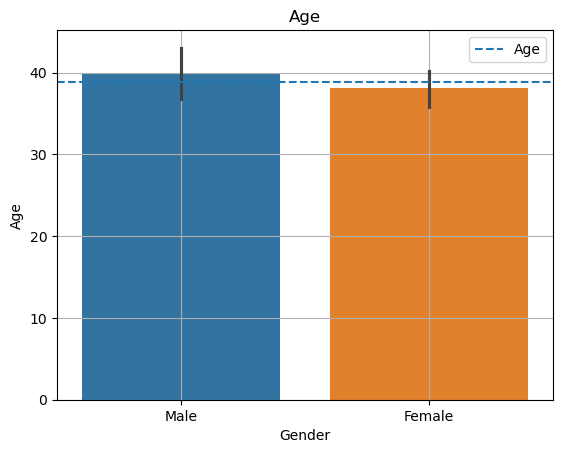

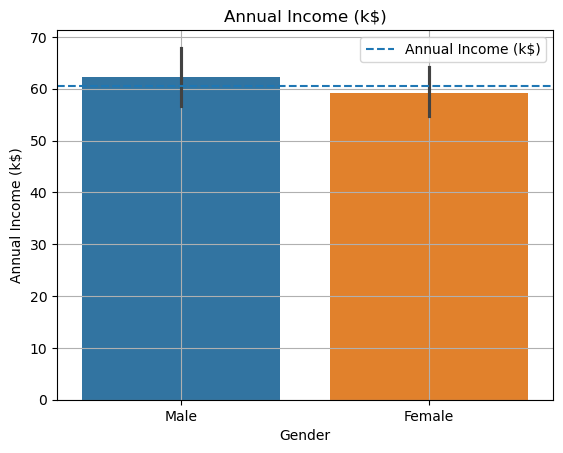

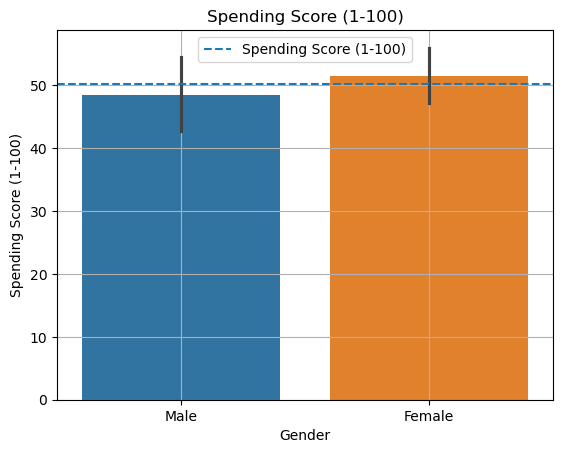

In [ ]:
visual_class.gender_visual(numeric_cols = ['Age', 'Annual Income (k$)', 'Spending Score (1-100)'])

- gender_info 메서드의 출력 결과를 나타내주세요
- 반복문의 종료 조건도 정확하게 준수해주세요

In [ ]:
'''
Q9 메서드의 출력 결과를 나타내주세요
반복문의 종료 조건도 정확하게 준수해주세요

메서드 : gender_info()
'''

visual_class.gender_info()

성별 정보입니다. : ['Male' 'Female']
조회하고자 하는 성별 정보를 입력하세요. 전체 정보를 원하시면 "전체"를 입력해주세요
[성별], [전체] 외의 정보를 입력시에 반복문은 종료됩니다.
입력값은 : Male


,CustomerID,Age,Annual Income (k$),Spending Score (1-100)
count,88.000000,88.000000,88.000000,88.000000
mean,104.238636,39.806818,62.227273,48.511364
std,57.483830,15.514812,26.638373,27.896770
min,1.000000,18.000000,15.000000,1.000000
25%,59.500000,27.750000,45.500000,24.500000
50%,106.500000,37.000000,62.500000,50.000000
75%,151.250000,50.500000,78.000000,70.000000
max,200.000000,70.000000,137.000000,97.000000


입력값은 : 전체


,CustomerID,Age,Annual Income (k$),Spending Score (1-100)
count,200.000000,200.000000,200.000000,200.000000
mean,100.500000,38.850000,60.560000,50.200000
std,57.879185,13.969007,26.264721,25.823522
min,1.000000,18.000000,15.000000,1.000000
25%,50.750000,28.750000,41.500000,34.750000
50%,100.500000,36.000000,61.500000,50.000000
75%,150.250000,49.000000,78.000000,73.000000
max,200.000000,70.000000,137.000000,99.000000


입력값은 : 남자
해당 정보는 존재하지 않습니다. 반복문을 종료합니다.


# Q8~Q10. Git 작업을 수행해주세요

---
- 첨부된 9주차_Git_문제.pdf 혹은 ppt 파일을 따라 Git 작업을 수행해주세요

※ 제출 방법
- GitHub 링크를 제출해주시면 됩니다.

## **🔎 [주관식 과제 수행 시 유의사항]**

> **✅ 1. 정확한 출력값과 요구사항 이행 필수**  

주관식 채점은 다음 기준에 따라 평가됩니다.

1)출력 결과의 정확성  
- 제공된 예시 결과와 동일한 출력이 나와야 합니다.  
- 단, 실시간 데이터나 인공지능 학습 등으로 출력값에 변동성이 존재할 수 있는 문제는 예외로 처리합니다.  

2)문제 요구사항의 충실한 반영  
- 조건, 컬럼명, 출력 형식 등 모든 요구사항을 빠짐없이 반영해야 합니다.  
- 사소한 조건도 놓치지 않도록 세심하게 코드를 작성해 주세요.  


> **✅ 2. 완성된 코드 제출 필수**

가. 제출한 코드 셀은 채점 시 직접 실행하여 결과를 확인할 수 있습니다.  

- 재실행 시에도 동일한 결과가 나와야 정답으로 인정됩니다.  

나. 버전 차이에 따른 미세한 수치 차이는 감안하나, 결과 형태나 구조가 다르면 감점 또는 오답 처리될 수 있습니다.  

다. 시각화 문제에서 색상 지정이 없다면, 기본(default) 색상 사용을 전제로 합니다.  
- 환경에 따라 색상이 다르게 출력되더라도 불이익은 없습니다.  

> **✅ 3. 사용자 선언 함수/클래스 문제 주의사항**

사용자 정의 함수, 클래스, 메서드와 관련된 문제에서는 추가적인 코드 없이도 함수만으로 정답 결과가 도출되어야 합니다.  
- ❌ 함수 외부에서 plt.title, print, info() 등을 추가하여 결과를 보완하면 오답 처리됩니다.  

> **✅ 4. 함수/클래스 선언 시 일관된 결과 유지**

가. 함수, 클래스, 메서드는 반복 실행 시에도 항상 동일한 결과를 반환해야 합니다.  
나. 채점 중 재실행 결과가 다르면 오답으로 처리됩니다.  

> **📌 [안내 정리]**  

가. 문제의 모든 조건을 꼼꼼히 확인하고 반영해 주세요.  
나. 과제는 실무와 유사한 기준으로 평가되며, 요구 조건을 충족하지 않을 경우 0점 처리될 수 있습니다.  

## ※ 과제 안내 2

8주차 과제부터는 셀 출력 결과에서 모든 요소가 정확히 반영될 수 있도록 꼼꼼하게 검토해주시길 바랍니다!  
현재까지 학습 보고서를 통해 세심한 피드백을 제공해드렸으니,  
해당 내용을 참고하시면 도움이 될 것입니다.  
작은 부분도 오답의 요인이 될 수 있으며, 부분 점수 없이 정답 여부를 기준으로 평가됩니다.  

아래는 현재까지 제공된 피드백의 일부 예시입니다.  

📌 피드백 예시  

[정렬] 다음에는 정렬 순서까지 맞춰주세요. 이후에는 오답 처리될 수 있습니다.  
[출력 형식] 답안지와 동일한 형식으로 데이터프레임을 출력해주세요.  
과제 제출 전, 위 사항을 다시 한번 점검해 주세요!  